# BÁO CÁO PHÂN TÍCH HIỆU NĂNG VÀ ĐỘ ỔN ĐỊNH CỦA CÁC THUẬT TOÁN GIẢI HỆ PHƯƠNG TRÌNH TUYẾN TÍNH

Báo cáo này thực hiện so sánh ba phương pháp:

1. **Gaussian Elimination**: Phương pháp trực tiếp.
2. **SVD Decomposition**: Phương pháp dựa trên phân tích ma trận.
3. **Gauss-Seidel**: Phương pháp lặp.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # hoặc đường dẫn tới project root
from part3.benchmark import benchmark, plot_results, stability_analysis

### 1. Thực nghiệm Hiệu năng (Benchmarking)

Chúng ta sẽ đo thời gian thực thi của từng phương pháp khi kích thước ma trận $n$ tăng dần.

In [2]:
sizes = [20, 50, 80, 100]

In [3]:
df_benchmark = benchmark(sizes)
display(df_benchmark.pivot(index="n", columns="Method", values="Time"))

Generated SPD matrix of size 20 in 0.0040 seconds.
Generated SPD matrix of size 50 in 0.0361 seconds.
Generated SPD matrix of size 80 in 0.1689 seconds.
Generated SPD matrix of size 100 in 0.2149 seconds.


Method,Gauss,Gauss-Seidel,SVD
n,,,
20,0.004709,0.003142,0.622341
50,0.034294,0.052663,8.872906
80,0.128175,0.246207,36.850499
100,0.137167,0.438159,62.925034


In [7]:
display(df_benchmark.pivot(index="n", columns="Method", values="Error"))

Method,Gauss,Gauss-Seidel,SVD
n,,,
20,1.382251e-16,1.324105e-11,0.000464
50,2.334578e-16,2.162051e-11,0.000291
80,2.202055e-16,3.027262e-11,0.000207
100,2.853347e-16,2.264465e-11,0.000226


### 2. Biểu đồ Thời gian thực thi (Log-Log Plot)

Sử dụng biểu đồ Log-Log để kiểm chứng độ phức tạp thuật toán $O(n^3)$.

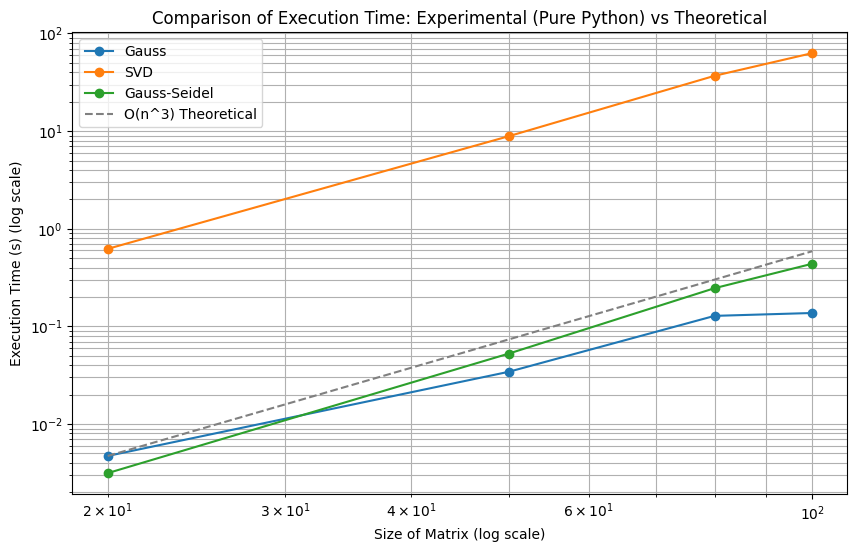

In [5]:
plot_results(df_benchmark, sizes)

### 3. Phân tích Độ ổn định (Stability Analysis)

Chúng ta so sánh sai số khi giải hệ phương trình với **Ma trận Hilbert** (xấu) và **Ma trận SPD** (tốt). Ma trận Hilbert có các hàng gần như phụ thuộc tuyến tính, khiến các sai số làm tròn nhỏ nhất cũng bị phóng đại.

In [6]:
df_analysis = stability_analysis(5)
display(df_analysis)


Stability Analysis (n=5):


,Method,Error Hilbert,Error SPD
0,Gauss,1.681451e-14,1.110223e-16
1,SVD,1.125167e+00,1.170385e-03
